・帰無仮説：２年間で減少するバッテリー容量は１割である

・対立仮説：２年間で減少するバッテリー容量は１割とは異なる

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme()

In [3]:
data=pd.read_csv("batteries_hours.csv")
data.head()

,new,year2
0,200.614633,181.027960
1,199.716863,164.124190
2,205.733141,171.638352
3,193.768958,174.801830
4,206.248877,198.362352


In [4]:
data.describe()

,new,year2
count,500.000000,500.000000
mean,200.474637,176.402151
std,4.794669,8.291210
min,184.437132,156.141821
25%,196.886113,170.442397
50%,200.492489,176.108870
75%,203.582387,182.191932
max,216.199636,198.849765


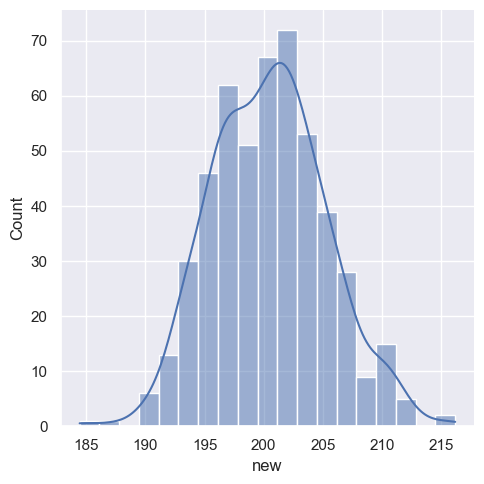

In [5]:
#newについてグラフ表示
sns.displot(data["new"],kde=True)

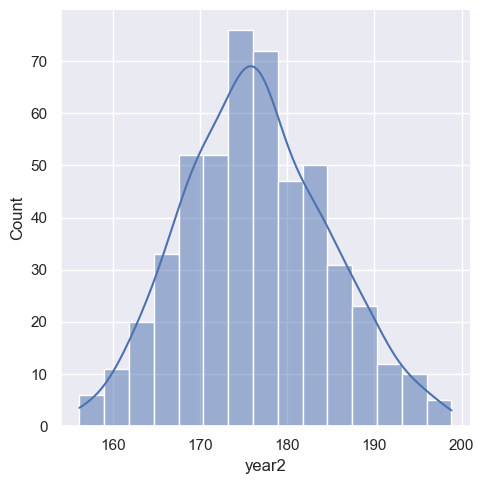

In [6]:
#year2についてグラフ表示
sns.displot(data["year2"],kde=True)

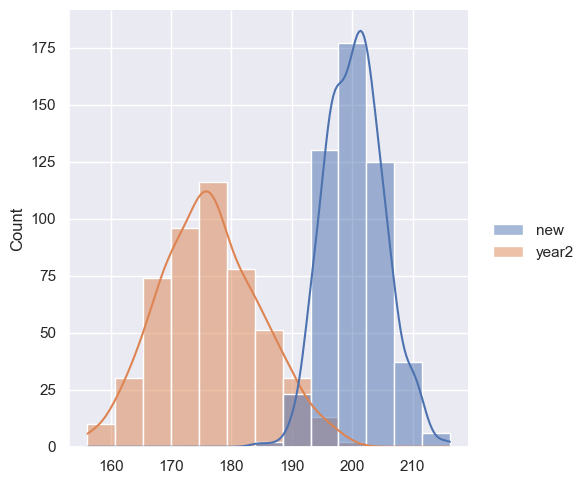

In [7]:
#newとyear2を重ねて表示
sns.displot(data,kde=True)

In [ ]:
#母平均の推定値を算出(点推定)
mu=np.mean(data["new"])
print("newの母平均の推定値：",mu)

mu2=np.mean(data["year2"])
print("year2の母平均の推定値：",mu2)

newの母平均の推定値： 200.4746372262155
year2の母平均の推定値： 176.40215071111032


In [16]:
#母分散の推定値を算出（点推定）
sigma2_n=np.var(data["new"],ddof=1)
print("newの母分散の推定値：",sigma2_n)

sigma2_y=np.var(data["year2"],ddof=1)
print("year2の母分散の推定値：",sigma2_y)

newの母分散の推定値： 22.988848478054507
year2の母分散の推定値： 68.74415625640519


In [19]:
#標準誤差を算出
sigma_n=np.std(data["new"],ddof=1)
se_n=sigma_n/np.sqrt(len(data["new"]))
print("newの標準誤差：",se_n)

sigma_y=np.std(data["year2"],ddof=1)
se_y=sigma_y/np.sqrt(len(data["new"]))
print("year2の標準誤差：",se_y)


newの標準誤差： 0.21442410535224113
year2の標準誤差： 0.37079416461537035


In [22]:
#95%信頼区間の下限値と上限値を算出
df_n=len(data["new"])-1
interval_n=stats.t.interval(0.95,df_n,loc=mu,scale=se_n)
print("newの95%信頼区間の上限値と下限値：",interval_n)

df_y=len(data["year2"])-1
interval_y=stats.t.interval(0.95,df_y,loc=mu2,scale=se_y)
print("year2の95%信頼区間の上限値と下限値：",interval_y)

newの95%信頼区間の上限値と下限値： (np.float64(200.0533518842937), np.float64(200.89592256813728))
year2の95%信頼区間の上限値と下限値： (np.float64(175.6736405178838), np.float64(177.13066090433685))


In [24]:
#newとyear2の時間差を算出
data["difference"]=data["new"]-data["year2"]
data.head()

,new,year2,difference
0,200.614633,181.027960,19.586673
1,199.716863,164.124190,35.592673
2,205.733141,171.638352,34.094789
3,193.768958,174.801830,18.967128
4,206.248877,198.362352,7.886525


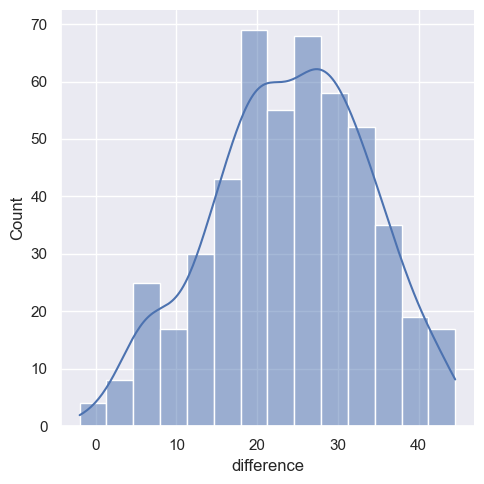

In [25]:
sns.displot(data["difference"],kde=True)

In [26]:
stats.ttest_1samp(data["difference"],20)

TtestResult(statistic=np.float64(9.465273816769793), pvalue=np.float64(1.159466251292928e-19), df=np.int64(499))

p値が0.05を下回ったので、優位差ありで帰無仮説を棄却する。つまり「２年間で減少するバッテリー容量は１割と異なる」という判断に至る。